<a href="https://colab.research.google.com/github/thiselvan/ml-project/blob/main/Lesson_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load our dataset for today — a housing price dataset
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)


print("Dataset loaded.")
print(f"Shape: {df.shape}")

Dataset loaded.
Shape: (20640, 10)


Exploratory Data Analysis

In [ ]:
# How big is the dataset?
print("Shape:", df.shape)


# What are the columns?
print("\nColumns:")
print(df.columns.tolist())


# What data type is each column?
print("\nData Types:")
print(df.dtypes)


Shape: (20640, 10)

Columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


In [ ]:
# Count missing values per column
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)


Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [ ]:
# Express as a percentage of total rows
print("\nMissing as % of total:")
print((missing / len(df) * 100).round(2))


Missing as % of total:
longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64


In [ ]:
# Look at the first 5 rows
print(df.head())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


In [ ]:
# Look at a random sample — sometimes more revealing than the first rows
print(df.sample(5, random_state=10))

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
20303    -119.18     34.16                12.0        460.0           101.0   
16966    -122.31     37.55                27.0       3931.0           933.0   
10623    -117.77     33.67                12.0       4329.0          1068.0   
6146     -117.95     34.11                29.0       1986.0           448.0   
2208     -119.87     36.81                 6.0       1891.0           341.0   

       population  households  median_income  median_house_value  \
20303       405.0       103.0         5.2783            167400.0   
16966      1877.0       851.0         3.9722            354100.0   
10623      1913.0       978.0         4.5094            160200.0   
6146       2013.0       432.0         3.1034            140800.0   
2208        969.0       330.0         4.6726            107800.0   

      ocean_proximity  
20303      NEAR OCEAN  
16966      NEAR OCEAN  
10623       <1H OCEAN  
6146           INLAN

In [ ]:
print(df.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

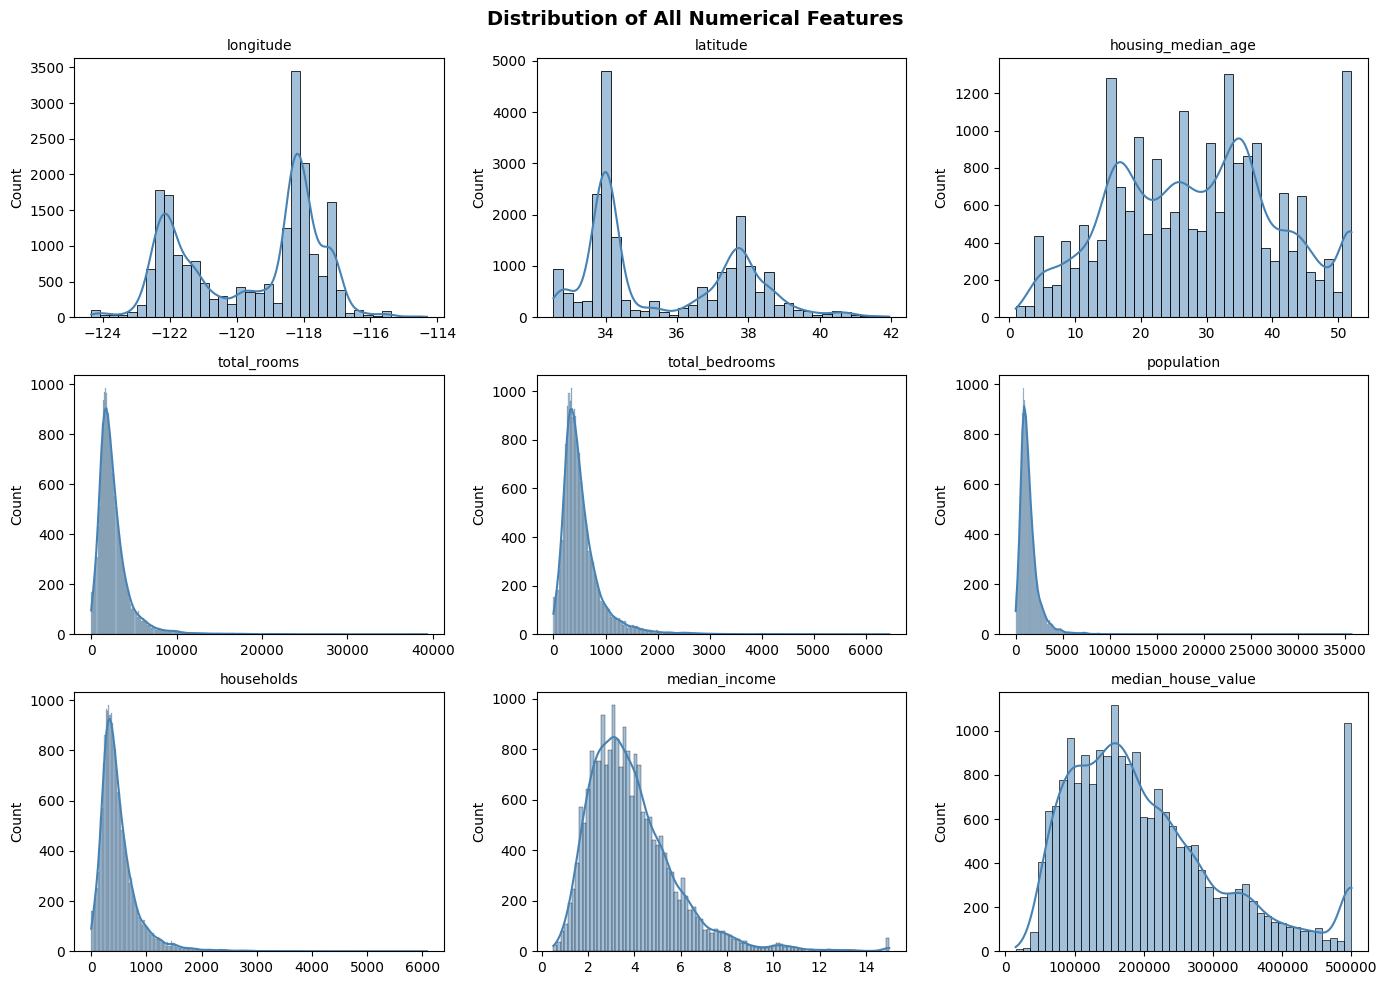

In [ ]:
# Plot distributions for all numerical columns at once
numerical_cols = df.select_dtypes(include="number").columns


fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()   # Convert 3x3 grid to a flat list for easy looping


for i, col in enumerate(numerical_cols):
   sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="steelblue")
   axes[i].set_title(col, fontsize=10)
   axes[i].set_xlabel("")


plt.suptitle("Distribution of All Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
# Calculate skewness for every numerical column
skewness = df.select_dtypes(include="number").skew().sort_values(ascending=False)
print("Skewness by column:")
print(skewness.round(2))

# -0.5 to 0.5 -> normal range
# -1 and 1

Skewness by column:
population            4.94
total_rooms           4.15
total_bedrooms        3.46
households            3.41
median_income         1.65
median_house_value    0.98
latitude              0.47
housing_median_age    0.06
longitude            -0.30
dtype: float64


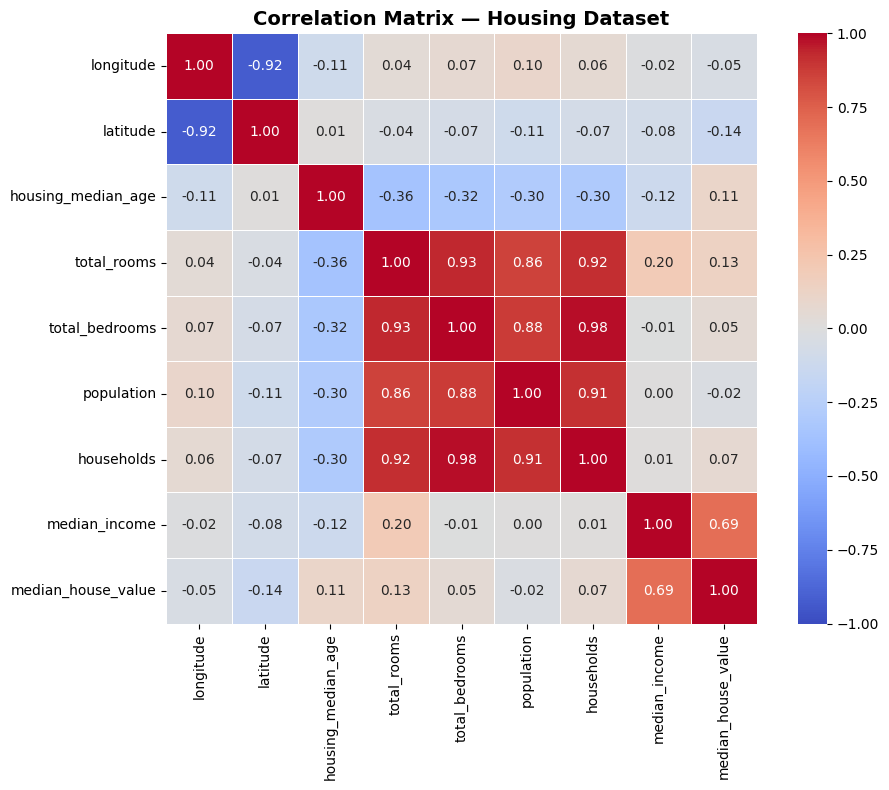

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


# Step 1: Compute the correlation matrix
corr_matrix = df.select_dtypes(include="number").corr()


# Step 2: Build the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
   corr_matrix,
   annot=True,
   fmt=".2f",
   cmap="coolwarm",
   vmin=-1,
   vmax=1,
   square=True,
   linewidths=0.5
)
plt.title("Correlation Matrix — Housing Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [ ]:
def detect_outliers_iqr(dataframe, column):
   Q1 = dataframe[column].quantile(0.25)
   Q3 = dataframe[column].quantile(0.75)
   IQR = Q3 - Q1

   lower_bound = Q1 - 1.5 * IQR
   upper_bound = Q3 + 1.5 * IQR

   outliers = dataframe[
       (dataframe[column] < lower_bound) |
       (dataframe[column] > upper_bound)
   ]

   print(f"Column: {column}")
   print(f"  Lower bound: {lower_bound:.2f}")
   print(f"  Upper bound: {upper_bound:.2f}")
   print(f"  Outliers found: {len(outliers)} ({len(outliers)/len(dataframe)*100:.1f}%)")
   return outliers


# Run on total_rooms — the most skewed column we found
outliers_rooms = detect_outliers_iqr(df, "total_rooms")


Column: total_rooms
  Lower bound: -1102.62
  Upper bound: 5698.38
  Outliers found: 1287 (6.2%)
